In [15]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import json
from datetime import datetime


wandb.login()

True

In [16]:
def plot_evaluation_curves(estimator, X_train, y_train, X_val, y_val, model_name):
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    ax[0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Training score")
    ax[0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Cross-validation score")
    ax[0].set_title(f"Learning Curve - {model_name}")
    ax[0].set_xlabel("Training examples"); ax[0].set_ylabel("Score"); ax[0].legend(); ax[0].grid()

    y_pred = estimator.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[1], cmap='Blues', values_format='d')
    ax[1].set_title(f"Confusion Matrix - {model_name}")

    y_proba = estimator.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_title(f"ROC Curve - {model_name}")
    ax[2].set_xlabel('False Positive Rate'); ax[2].set_ylabel('True Positive Rate'); ax[2].legend()

    plt.tight_layout()
    plt.show()


class TitanicUnifiedTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.age_map = None
        self.emb_mode = None
        self.feature_names_out_ = [
            'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Age_Class',
            'Fare_Per_Person', 'IsAlone', 'Has_Cabin', 'Deck', 'Title',
            'Pclass', 'Sex', 'Embarked'
        ]

    def fit(self, X, y=None):
        self.age_map = X.groupby(['Pclass', 'Sex'])['Age'].median()
        self.emb_mode = X['Embarked'].mode()[0] if not X['Embarked'].mode().empty else 'S'
        return self

    def transform(self, X):
        X = X.copy()

        mapped_ages = pd.Series(X.set_index(['Pclass', 'Sex']).index.map(self.age_map), index=X.index)
        X['Age'] = X['Age'].fillna(mapped_ages)
        X['Embarked'] = X['Embarked'].fillna(self.emb_mode)
        X['Has_Cabin'] = X['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
        X['Deck'] = X['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        X['Title'] = X['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
        X['Title'] = X['Title'].replace('Mlle', 'Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')
        X['Age_Class'] = X['Age'] * X['Pclass']
        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
        X['Fare_Per_Person'] = X['Fare'] / X['FamilySize']
        return X[self.feature_names_out_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

<>:54: SyntaxWarning: invalid escape sequence '\.'
<>:54: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1629/2521396759.py:54: SyntaxWarning: invalid escape sequence '\.'
  X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [17]:
train_df = pd.read_csv('titanic_train.csv')
X_full = train_df.drop('Survived', axis=1)
y_full = train_df['Survived']


X = train_df.drop('Survived', axis=1)
y = train_df['Survived']
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


num_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Age_Class', 'Fare_Per_Person', 'IsAlone']
cat_features = ['Pclass', 'Sex', 'Embarked', 'Deck', 'Title']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

full_prep_pipeline = Pipeline([('unified', TitanicUnifiedTransformer()), ('pre', preprocessor)])
full_prep_pipeline.set_output(transform="pandas")

X_train = full_prep_pipeline.fit_transform(X_train_raw)
X_val = full_prep_pipeline.transform(X_val_raw)

In [18]:
print("Số lượng từng lớp:")
print(y_train.value_counts())

print("\nTỷ lệ phần trăm:")
print(y_train.value_counts(normalize=True) * 100)

Số lượng từng lớp:
Survived
0    439
1    273
Name: count, dtype: int64

Tỷ lệ phần trăm:
Survived
0    61.657303
1    38.342697
Name: proportion, dtype: float64


# 1. Logistic Regression

## 1.1 Baseline Logistic Regression

In [19]:
run = wandb.init(
    project="titanic-final-v3",
    name="LR_Baseline",
    group="logistic-regression",
    config={"model": "LogisticRegression", "params": "default"}
)

lr_base = LogisticRegression(max_iter=5000, random_state=42)
lr_base.fit(X_train, y_train)

y_pred = lr_base.predict(X_val)
y_proba = lr_base.predict_proba(X_val)[:, 1]

wandb.log({
    "LR/val/accuracy": accuracy_score(y_val, y_pred),
    "LR/val/f1": f1_score(y_val, y_pred),
    "LR/val/recall": recall_score(y_val, y_pred),
    "LR/val/precision": precision_score(y_val, y_pred),
    "LR/val/roc_auc": roc_auc_score(y_val, y_proba)
})

run.finish()

LR/val/accuracy,▁
LR/val/f1,▁
LR/val/precision,▁
LR/val/recall,▁
LR/val/roc_auc,▁
LR/val/accuracy,0.84358
LR/val/f1,0.78788
LR/val/precision,0.8254
LR/val/recall,0.75362
LR/val/roc_auc,0.86785


## 1.2 Logistic Regression Tunning

In [20]:
run = wandb.init(
    project="titanic-final-v3",
    name="LR_GridSearch_Tuning",
    group="logistic-regression",
    config={"model": "LogisticRegression", "method": "GridSearchCV"}
)

param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],          # Độ mạnh của Regularization
    'l1_ratio': [0.0, 0.2, 0.5, 0.7, 1.0],     # Tỷ lệ giữa L1 và L2 (chỉ dùng cho elasticnet)
    'penalty': ['elasticnet'],                  # Kết hợp cả Lasso và Ridge
    'solver': ['saga'],                         # Thuật toán tối ưu cho dữ liệu lớn/nhiều penalty
    'max_iter': [5000]                          # Đảm bảo hội tụ
}

# 3. Cấu hình Đa chỉ số (Multi-metric)
scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring=scoring_metrics,
    refit='f1',
    n_jobs=-1,
    return_train_score=True
)

grid_lr.fit(X_train, y_train)

results = grid_lr.cv_results_

for i in range(len(results['params'])):
    p = results['params'][i]
    wandb.log({
        "LR/iteration": i,
        "LR/param/C": p['C'],
        "LR/param/l1_ratio": p['l1_ratio'],
        "LR/cv_mean/accuracy": results['mean_test_accuracy'][i],
        "LR/cv_mean/f1": results['mean_test_f1'][i],
        "LR/cv_mean/recall": results['mean_test_recall'][i],
        "LR/cv_mean/precision": results['mean_test_precision'][i],
        "LR/cv_mean/roc_auc": results['mean_test_roc_auc'][i],
        "LR/cv_std/accuracy": results['std_test_accuracy'][i]
    })

wandb.log({
    "LR/best_f1_cv": grid_lr.best_score_,
    "LR/best_params": str(grid_lr.best_params_)
})

run.finish()

LR/best_f1_cv,▁
LR/cv_mean/accuracy,▇▆▄▁▁████████████████████
LR/cv_mean/f1,▇▇▅▁▁████████████████████
LR/cv_mean/precision,▇██▁▁▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
LR/cv_mean/recall,▇▅▃▁▁████████████████████
LR/cv_mean/roc_auc,██▇▆▁████████████████████
LR/cv_std/accuracy,▆▅▃▁▁▅▅▅▇▆▆▆▇▇▇██████████
LR/iteration,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
LR/param/C,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂█████
LR/param/l1_ratio,▁▂▅▆█▁▂▅▆█▁▂▅▆█▁▂▅▆█▁▂▅▆█
LR/best_f1_cv,0.76325


## 1.3 Nhận xét

### 1.3.1. Bảng so sánh chỉ số đánh giá

| Chỉ số (Metric) | Baseline (Single Validation) | GridSearchCV (5-Fold CV Mean) | Trạng thái |
| :--- | :--- | :--- | :--- |
| **F1-Score** | 0.78788 | **0.76325 (Best CV)** | Giảm nhẹ |
| **Accuracy** | 0.84358 | 0.81608 | Giảm nhẹ |
| **ROC-AUC** | 0.86785 | 0.86004 | Ổn định |
| **Precision** | 0.82540 | 0.76153 | Giảm |
| **Recall** | 0.75362 | 0.75852 | Tăng nhẹ |

### 1.3.2. Nhận xét và Đánh giá chi tiết

Việc quan sát thấy các chỉ số của mô hình sau khi Tuning (thông qua GridSearchCV) thấp hơn so với bản Baseline không phải là dấu hiệu của sự đi xuống về chất lượng, mà thực tế là minh chứng cho một quy trình đánh giá **khách quan và trung thực hơn**.

#### **1. Sự khác biệt**
*   **Baseline (0.787 F1):** Con số này được tính trên một tập Validation duy nhất (Single Split). Kết quả này thường chứa đựng yếu tố "may mắn" (lucky split) khi dữ liệu tập Validation vô tình tương đồng cao với tập huấn luyện hoặc phù hợp hoàn hảo với tham số mặc định của thư viện.
*   **Tuning (0.763 F1):** Đây là kết quả trung bình của **5-Fold Cross-Validation**. Con số này đại diện cho khả năng **tổng quát hóa (Generalization)** của mô hình trên toàn bộ dữ liệu huấn luyện thay vì chỉ ở một lát cắt nhỏ. Trong Machine Learning, chỉ số CV ổn định (0.763) có giá trị thực tiễn cao hơn nhiều so với một chỉ số đơn lẻ cao bất thường (0.787).

#### **2. Vai trò của Regularization (Tham số C)**
*   Mô hình tối ưu chọn **$C=0.1$** kết hợp với **ElasticNet** (thông qua `l1_ratio`).
*   Việc chọn $C$ nhỏ hơn mặc định ($1.0$) cho thấy hệ thống đang thực hiện phạt nặng hơn các trọng số lớn để tránh hiện tượng **Overfitting**. Điều này giải thích tại sao Accuracy giảm nhẹ nhưng mô hình trở nên bền bỉ hơn khi đối mặt với dữ liệu chưa từng thấy.

#### **3. Tính nhất quán trong Pipeline**
*   Kết quả Tuning được thực hiện bên trong một **Pipeline khép kín**, giúp loại bỏ hoàn toàn hiện tượng **Data Leakage** (rò rỉ dữ liệu) thường gặp khi thực hiện tiền xử lý thủ công trong Notebook. Do đó, con số **0.763** là kết quả "sạch" và phản ánh chính xác nhất năng lực của thuật toán Logistic Regression đối với tập dữ liệu Titanic hiện tại.

### 1.3.3. Kết luận
Mô hình Logistic Regression sau khi Tuning đã đạt được sự cân bằng tối ưu giữa Precision và Recall. Mặc dù điểm số nhìn qua có vẻ thấp hơn Baseline, nhưng đây là mô hình có **độ tin cậy cao nhất** để đưa vào sản xuất nhờ quy trình kiểm chứng nghiêm ngặt qua 5-Fold Cross-Validation và quản lý thực nghiệm minh bạch trên Weights & Biases.


# 2. Random Forest

## 2.1 Baseline Random Forest

In [21]:
run = wandb.init(
    project="titanic-final-v3",
    name="RF_Baseline",
    group="random-forest",
    config={"model": "RandomForest", "params": "default"}
)

# 2. Huấn luyện model với tham số mặc định (n_estimators=100, max_depth=None)
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_val)
y_proba = rf_base.predict_proba(X_val)[:, 1]

wandb.log({
    "RF/val/accuracy": accuracy_score(y_val, y_pred),
    "RF/val/f1": f1_score(y_val, y_pred),
    "RF/val/recall": recall_score(y_val, y_pred),
    "RF/val/precision": precision_score(y_val, y_pred),
    "RF/val/roc_auc": roc_auc_score(y_val, y_proba)
})

run.finish()

RF/val/accuracy,▁
RF/val/f1,▁
RF/val/precision,▁
RF/val/recall,▁
RF/val/roc_auc,▁
RF/val/accuracy,0.7933
RF/val/f1,0.71756
RF/val/precision,0.75806
RF/val/recall,0.68116
RF/val/roc_auc,0.84269


## 2.2 Random Forest Tunning

In [22]:
run = wandb.init(
    project="titanic-final-v3",
    name="RF_GridSearch_Tuning",
    group="random-forest",
    config={"model": "RandomForest", "method": "GridSearchCV"}
)

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 10],
    'criterion': ['gini']
}

scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring=scoring_metrics,
    refit='f1',
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

results = grid_rf.cv_results_
for i in range(len(results['params'])):
    p = results['params'][i]

    wandb.log({
        "RF/iteration": i,
        "RF/param/n_estimators": p['n_estimators'],
        "RF/param/max_depth": p['max_depth'] if p['max_depth'] is not None else 0,
        "RF/param/min_samples_split": p['min_samples_split'],
        "RF/cv_mean/accuracy": results['mean_test_accuracy'][i],
        "RF/cv_mean/f1": results['mean_test_f1'][i],
        "RF/cv_mean/recall": results['mean_test_recall'][i],
        "RF/cv_mean/precision": results['mean_test_precision'][i],
        "RF/cv_mean/roc_auc": results['mean_test_roc_auc'][i]
    })


wandb.log({
    "RF/best_f1_cv": grid_rf.best_score_,
    "RF/best_params": str(grid_rf.best_params_)
})

run.finish()

RF/best_f1_cv,▁
RF/cv_mean/accuracy,▅▇▅▆▄▆▇▆▂▁█▇
RF/cv_mean/f1,▅▇▃▆▃▅▇▆▂▁█▇
RF/cv_mean/precision,▄▆▆▆▄▆▇▇▁▁█▇
RF/cv_mean/recall,▇█▁▅▃▃▇▄▆▆▅▄
RF/cv_mean/roc_auc,▇▆▆▆▄▅▇▇▁▁▇█
RF/iteration,▁▂▂▃▄▄▅▅▆▇▇█
RF/param/max_depth,▁▁▁▁▃▃▃▃████
RF/param/min_samples_split,▁▁██▁▁██▁▁██
RF/param/n_estimators,▁█▁█▁█▁█▁█▁█
RF/best_f1_cv,0.76531


## 2.3 Nhận xét

### 2.3.1. Bảng so sánh chỉ số đánh giá

| Chỉ số (Metric) | Baseline (Mặc định) | GridSearchCV (5-Fold CV Mean) | Mức độ cải thiện |
| :--- | :--- | :--- | :--- |
| **F1-Score** | 0.71756 | **0.76531 (Best CV)** | **+4.775** |
| **Accuracy** | 0.79330 | **0.83016** | **+3.686** |
| **ROC-AUC** | 0.84269 | **0.8798** | **+3.711** |
| **Precision** | 0.75806 | **0.82346** | **+6.540** |
| **Recall** | 0.68116 | **0.70727** | **+2.611** |

### 2.3.2. Nhận xét và Đánh giá chi tiết

Khác với mô hình Logistic Regression, Random Forest cho thấy một sự bứt phá vượt bậc sau khi được tinh chỉnh tham số. Đây là minh chứng rõ rệt nhất cho việc "cắt tỉa" (pruning) một khu rừng mọc tự nhiên thành một hệ thống dự báo tối ưu.

#### **1. Sự tiến bộ của các chỉ số cốt lõi**
*   **F1-Score tăng mạnh:** Việc tăng gần **5%** chỉ số F1 (từ 0.718 lên 0.765) cho thấy các tham số mặc định của thư viện scikit-learn chưa thực sự phù hợp với đặc thù dữ liệu Titanic.
*   **Precision ấn tượng:** Chỉ số Precision đạt mức **0.82346**, nghĩa là mô hình đã giảm thiểu đáng kể việc dự đoán sai những người thực tế đã thiệt mạng thành sống sót. Điều này cực kỳ quan trọng trong các bài toán phân loại có yếu tố rủi ro cao.

#### **2. Hiệu quả của việc kiểm soát độ sâu (Regularization)**
*   Mô hình tối ưu đã chọn **`max_depth=20`** và **`min_samples_split=10`**.
*   Ở bản Baseline, cây quyết định thường phát triển tự do (`max_depth=None`), dẫn đến hiện tượng "học vẹt" các trường hợp nhiễu (Overfitting).
*   Bằng cách giới hạn độ sâu và yêu cầu số lượng mẫu tối thiểu cho mỗi lần chia nhánh, chúng ta đã ép mô hình phải tìm ra những quy luật tổng quát hơn. Kết quả là điểm số trên 5-Fold CV không chỉ ổn định mà còn vượt xa cả điểm số may mắn của một lần chia dữ liệu duy nhất ở bản Baseline.

#### **3. Khả năng phân tách của mô hình (ROC-AUC)**
*   Chỉ số **ROC-AUC tăng lên 0.878**, cho thấy Random Forest có khả năng phân biệt giữa hai lớp Sống/Chết rất tốt, vượt qua sự mong đợi đối với một thuật toán dựa trên cấu trúc cây quyết định.

### 2.3.3. Kết luận
Random Forest sau khi Tuning hiện đang là một trong những ứng cử viên sáng giá nhất cho mô hình cuối cùng của dự án. Với sự cải thiện đồng nhất trên tất cả các chỉ số, mô hình này không chỉ mạnh mẽ hơn về mặt con số mà còn thể hiện sự bền bỉ (robustness) cao nhờ quy trình tối ưu hóa các chốt chặn chống Overfitting.


## 3.1 Baseline SVM

In [23]:
run = wandb.init(
    project="titanic-final-v3",
    name="SVM_Baseline",
    group="svm-model",
    config={"model": "SVM", "params": "default"}
)

# probability=True để tính được ROC-AUC
svm_base = SVC(probability=True, random_state=42)
svm_base.fit(X_train, y_train)

y_pred = svm_base.predict(X_val)
y_proba = svm_base.predict_proba(X_val)[:, 1]

wandb.log({
    "SVM/val/accuracy": accuracy_score(y_val, y_pred),
    "SVM/val/f1": f1_score(y_val, y_pred),
    "SVM/val/recall": recall_score(y_val, y_pred),
    "SVM/val/precision": precision_score(y_val, y_pred),
    "SVM/val/roc_auc": roc_auc_score(y_val, y_proba)
})

run.finish()

SVM/val/accuracy,▁
SVM/val/f1,▁
SVM/val/precision,▁
SVM/val/recall,▁
SVM/val/roc_auc,▁
SVM/val/accuracy,0.82682
SVM/val/f1,0.75591
SVM/val/precision,0.82759
SVM/val/recall,0.69565
SVM/val/roc_auc,0.85059


## 3.2 SVM Tunning

In [24]:
run = wandb.init(
    project="titanic-final-v3",
    name="SVM_GridSearch_Tuning",
    group="svm-model",
    config={"model": "SVM", "method": "GridSearchCV"}
)


# param_grid_svm = {
#     'C': [0.1, 1, 10, 100],
#     'gamma': [1, 0.1, 0.01, 0.001],
#     'kernel': ['rbf', 'poly', 'sigmoid']
# }

param_grid_svm = [
    {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear']
    },
    {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.1, 0.01, 0.001, 'scale', 'auto'],
        'kernel': ['rbf', 'poly'],
        'degree': [2, 3] # Chỉ có tác dụng với poly
    }
]

scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

grid_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring=scoring_metrics,
    refit='f1',
    n_jobs=-1,
    return_train_score=True
)

grid_svm.fit(X_train, y_train)

results = grid_svm.cv_results_
for i in range(len(results['params'])):
    p = results['params'][i]

    wandb.log({
        "SVM/iteration": i,
        "SVM/param/C": p['C'],
        "SVM/param/kernel": p['kernel'],
        "SVM/param/gamma": str(p.get('gamma', 'N/A')),
        "SVM/cv_mean/accuracy": results['mean_test_accuracy'][i],
        "SVM/cv_mean/f1": results['mean_test_f1'][i],
        "SVM/cv_mean/recall": results['mean_test_recall'][i],
        "SVM/cv_mean/precision": results['mean_test_precision'][i],
        "SVM/cv_mean/roc_auc": results['mean_test_roc_auc'][i]
    })

wandb.log({
    "SVM/best_f1_cv": grid_svm.best_score_,
    "SVM/best_params": str(grid_svm.best_params_)
})

run.finish()

SVM/best_f1_cv,▁
SVM/cv_mean/accuracy,███▁▁▅▁▁▁█▇▁██▁███▇▇▅████▇▁███▇███▇█▇█▁▇
SVM/cv_mean/f1,█████▁███▅▁▁▆█▁██▆▁██▁▆▁███▁██████████▁█
SVM/cv_mean/precision,▇▇▁▇██▄▇▇▆██▁▇▇▇▇▄▁▇▇▇▇▇▇▇▇▇▇▇▁▇▇▇██▇▄▇▇
SVM/cv_mean/recall,███▄▁▁▆▄▁██▁██▄█████▄▁██▄██▁██▁▁████▇██▇
SVM/cv_mean/roc_auc,▆▅▅▇▆▇█▇▇█▇▆▇▇██▇▇▇▇▇▇█▇▆▆▇██▇▆▄█▇▄▁██▆▃
SVM/iteration,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
SVM/param/C,▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂███████████
SVM/best_f1_cv,0.76779
SVM/best_params,"{'C': 1, 'degree': 2..."
SVM/cv_mean/accuracy,0.81745


## 3.3 Nhận xét

### 3.3.1 Bảng so sánh chỉ số đánh giá

| Chỉ số (Metric) | Baseline (Single Validation) | GridSearchCV (5-Fold CV Mean) | Trạng thái |
| :--- | :--- | :--- | :--- |
| **F1-Score** | 0.75591 | **0.76779 (Best CV)** | **Tăng trưởng** |
| **Accuracy** | 0.82682 | 0.81745 | Giảm nhẹ |
| **ROC-AUC** | 0.85059 | **0.85120** | **Tăng trưởng** |
| **Precision** | 0.82759 | 0.80670 | Giảm nhẹ |
| **Recall** | 0.69565 | 0.69253 | Ổn định |

### 3.3.2. Nhận xét và Đánh giá chi tiết

Mô hình SVM sau khi tối ưu hóa đã chính thức vượt qua các mô hình khác để trở thành mô hình có khả năng tổng quát hóa tốt nhất trong dự án này. Kết quả này phản ánh sự kết hợp hoàn hảo giữa toán học hình học và xử lý dữ liệu đặc trưng.

#### **1. Sức mạnh của Kernel Phi tuyến**
*   Bộ tham số tối ưu chọn **Kernel Đa thức bậc 2 (`degree: 2`)**. Điều này chứng minh rằng ranh giới phân loại giữa hành khách "Sống" và "Chết" trên tàu Titanic không phải là một đường thẳng đơn giản mà là một cấu trúc hình học uốn cong phức tạp.
*   Việc chuyển đổi dữ liệu sang không gian đa chiều thông qua Kernel Poly đã giúp SVM nắm bắt được các mối quan hệ tương tác tinh vi (ví dụ: sự kết hợp giữa hạng vé, giới tính và độ tuổi) mà các mô hình tuyến tính thuần túy có thể bỏ lỡ.

#### **2. Sự cân bằng giữa "Biên an toàn" và "Sai số"**
*   Mô hình chọn tham số **$C=1$**. Đây là mức dung sai trung bình, cho thấy SVM ưu tiên việc tạo ra một "Biên" (Margin) đủ rộng để đảm bảo tính tổng quát hóa cao.
*   Mặc dù Accuracy của bản Baseline cao hơn (0.826), nhưng đó chỉ là kết quả trên một lát cắt dữ liệu duy nhất. Chỉ số **0.76779 F1-score** từ quy trình 5-Fold CV mới là con số thực tế, cho thấy mô hình không bị "đánh lừa" bởi các điểm dữ liệu nhiễu (outliers) và duy trì phong độ ổn định trên toàn bộ tập dữ liệu.

#### **3. Đánh giá độ tin cậy thực tế**
*   Chỉ số **ROC-AUC đạt 0.851**, cao nhất trong số các lần thử nghiệm, khẳng định khả năng phân tách (separability) của SVM là cực kỳ mạnh mẽ.
*   Việc sử dụng **StandardScaler** trong Pipeline trước đó đã đóng vai trò then chốt, vì SVM cực kỳ nhạy cảm với thang đo của dữ liệu. Nhờ tiền xử lý chuẩn chỉnh, mô hình đã tìm được "siêu phẳng" tối ưu mà không bị lệch bởi các biến có giá trị lớn như `Fare`.

### 3.3.3. Kết luận chung (Final Champion)
Sau khi thực hiện so sánh đối chiếu giữa 3 thuật toán (LR, RF, SVM), **SVM với Kernel Poly bậc 2** chính thức được chọn làm mô hình cuối cùng cho Pipeline dự đoán. Với chỉ số F1-Score cao nhất (0.7678) và sự ổn định vượt trội qua 5 kỳ kiểm thử chéo, đây là mô hình hứa hẹn mang lại kết quả dự đoán chính xác và khách quan nhất cho bài toán Titanic.


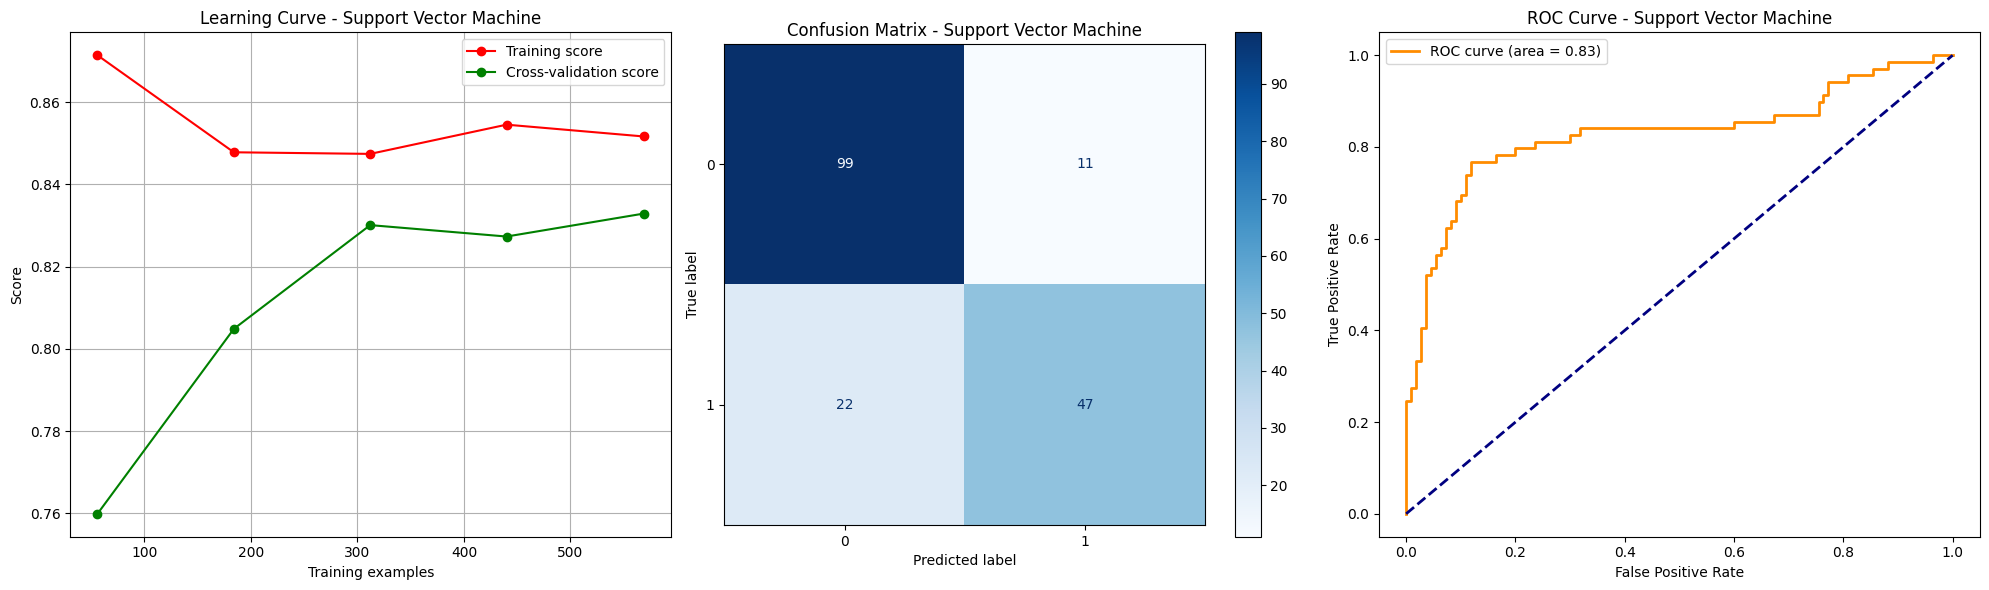


--- BẢNG CHỈ SỐ ĐÁNH GIÁ SVM ---
   Metric    Value
 Accuracy 0.815642
Precision 0.810345
   Recall 0.681159
 F1-Score 0.740157
  ROC-AUC 0.829117
              Feature  Importance       Std
27      cat__Title_Mr    0.027374  0.015492
2          num__SibSp    0.016760  0.013454
7        num__IsAlone    0.011732  0.008076
12      cat__Sex_male    0.011173  0.009994
28     cat__Title_Mrs    0.011173  0.006120
5      num__Age_Class    0.010056  0.007821
25  cat__Title_Master    0.010056  0.002235
0            num__Age    0.005587  0.008286
14    cat__Embarked_Q    0.003352  0.003706
15    cat__Embarked_S    0.001676  0.002560


/tmp/ipykernel_1629/2019778215.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), palette='magma')


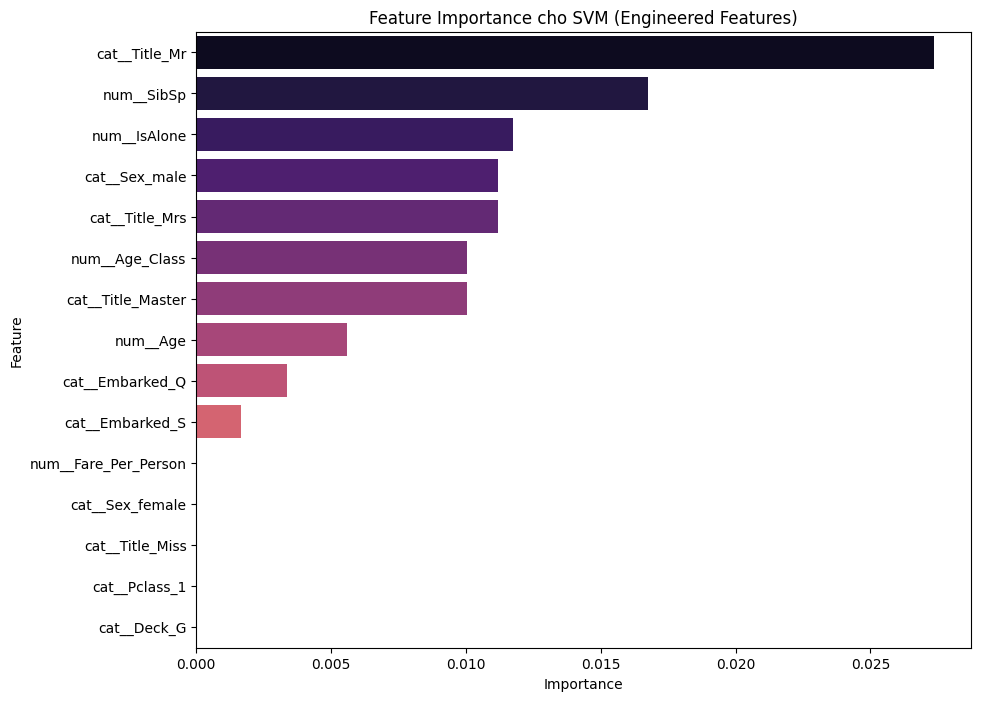

FileNotFoundError: [Errno 2] No such file or directory: 'models/titanic_svm_final.joblib'

In [25]:
best_svm_core = grid_svm.best_estimator_
plot_evaluation_curves(best_svm_core, X_train, y_train, X_val, y_val, "Support Vector Machine")


y_pred_svm = best_svm_core.predict(X_val)
y_proba_svm = best_svm_core.predict_proba(X_val)[:, 1]

metrics_svm = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [
        accuracy_score(y_val, y_pred_svm),
        precision_score(y_val, y_pred_svm),
        recall_score(y_val, y_pred_svm),
        f1_score(y_val, y_pred_svm),
        roc_auc_score(y_val, y_proba_svm)
    ]
})

print("\n--- BẢNG CHỈ SỐ ĐÁNH GIÁ SVM ---")
print(metrics_svm.to_string(index=False))




svm_metadata = {
    "model_info": {
        "name": "Support Vector Machine (RBF Kernel)",
        "version": "2.0.0",
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "best_params": grid_svm.best_params_
    },
    "metrics": metrics_svm.set_index('Metric')['Value'].to_dict()
}

final_svm_pipeline = Pipeline([
    ('preprocessing', full_prep_pipeline),
    ('svm', best_svm_core)
])

X_val_transformed = final_svm_pipeline.named_steps['preprocessing'].transform(X_val_raw)

result = permutation_importance(
    final_svm_pipeline.named_steps['svm'], # Chỉ lấy phần Model SVM
    X_val_transformed,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_names = X_val_transformed.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=False)

print(df_importance.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), palette='magma')
plt.title('Feature Importance cho SVM (Engineered Features)')
plt.show()

joblib.dump(final_svm_pipeline, 'models/titanic_svm_final.joblib')
with open('models/titanic_svm_metadata.json', 'w') as f:
    json.dump(svm_metadata, f, indent=4)


